# Mutual Fund Analytics - Exploratory Data Analysis

### Bluestock Fintech Internship Project

**Intern:** Bhagyouday

---

## Objective

The objective of this notebook is to perform an end-to-end Exploratory Data Analysis (EDA) on the Indian Mutual Fund dataset. The analysis focuses on identifying investment trends, fund performance, investor behaviour, portfolio allocation, market movements, and business insights using multiple datasets.

---

## Datasets Used

- Fund Master
- NAV History
- Investor Transactions
- Scheme Performance
- AUM by Fund House
- Monthly SIP Inflows
- Category Inflows
- Industry Folio Count
- Portfolio Holdings
- Benchmark Indices

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

---

## Workflow

1. Import Libraries
2. Load Datasets
3. Data Overview
4. NAV Analysis
5. AUM Analysis
6. SIP Analysis
7. Investor Analysis
8. Performance Analysis
9. Portfolio Analysis
10. Market Analysis
11. Key Insights

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [3]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav.csv")

transactions = pd.read_csv("../data/processed/clean_transactions.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

aum = pd.read_csv("../data/processed/clean_aum.csv")

sip = pd.read_csv("../data/processed/clean_sip_inflows.csv")

category = pd.read_csv("../data/processed/clean_category_inflows.csv")

folio = pd.read_csv("../data/processed/clean_folio_count.csv")

benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
datasets = {
    "Fund": fund,
    "NAV": nav,
    "Transactions": transactions,
    "Performance": performance,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Benchmark": benchmark,
    "Portfolio": portfolio,
}

for name, df in datasets.items():
    print(f"{name:15} {df.shape}")

Fund            (40, 15)
NAV             (46000, 3)
Transactions    (32778, 13)
Performance     (40, 19)
AUM             (90, 5)
SIP             (48, 6)
Category        (144, 3)
Folio           (21, 6)
Benchmark       (8050, 3)
Portfolio       (322, 8)


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
print(nav.info())

print("\nNumber of schemes:", nav["amfi_code"].nunique())

print("Date Range:")
print(nav["date"].min(), "to", nav["date"].max())

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB
None

Number of schemes: 40
Date Range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [7]:
nav.describe()

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
mean,120247.000000,2024-03-16 12:00:00,269.570265
min,100016.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2025-04-23 00:00:00,260.338675
max,149324.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,577.187060


In [8]:
daily_nav = (
    nav.groupby("date")["nav"]
    .mean()
    .reset_index()
)

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [9]:
import plotly.express as px

fig = px.line(
    daily_nav,
    x="date",
    y="nav",
    title="Average Daily NAV (2022–2026)",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="Average NAV",
    width=1100,
    height=500
)

fig.show()

In [10]:
daily_nav["MA30"] = daily_nav["nav"].rolling(30).mean()

In [11]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=daily_nav["date"],
        y=daily_nav["nav"],
        name="Daily NAV"
    )
)

fig.add_trace(
    go.Scatter(
        x=daily_nav["date"],
        y=daily_nav["MA30"],
        name="30-Day MA",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Average NAV with 30-Day Moving Average",
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

In [12]:
highest = daily_nav.loc[daily_nav["nav"].idxmax()]

highest

date    2026-04-20 00:00:00
nav              357.998873
MA30             350.855647
Name: 1120, dtype: object

In [13]:
lowest = daily_nav.loc[daily_nav["nav"].idxmin()]

lowest

date    2022-02-07 00:00:00
nav              206.628312
MA30                    NaN
Name: 25, dtype: object

In [14]:
print("Highest Average NAV")
print(highest)

print()

print("Lowest Average NAV")
print(lowest)

Highest Average NAV
date    2026-04-20 00:00:00
nav              357.998873
MA30             350.855647
Name: 1120, dtype: object

Lowest Average NAV
date    2022-02-07 00:00:00
nav              206.628312
MA30                    NaN
Name: 25, dtype: object


In [15]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [16]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [17]:
aum.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


In [18]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [19]:
top10 = (
    aum.groupby("fund_house")["aum_crore"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10

fund_house
SBI Mutual Fund             943444.444444
ICICI Prudential MF         699222.222222
HDFC Mutual Fund            636888.888889
Nippon India MF             434333.333333
Kotak Mahindra MF           389111.111111
Aditya Birla Sun Life MF    341888.888889
UTI Mutual Fund             297888.888889
Axis Mutual Fund            280111.111111
Mirae Asset MF              173444.444444
DSP Mutual Fund             156555.555556
Name: aum_crore, dtype: float64

In [20]:
import plotly.express as px

fig = px.bar(
    top10.reset_index(),
    x="fund_house",
    y="aum_crore",
    title="Top 10 Fund Houses by Average AUM",
    text="aum_crore"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=550,
    xaxis_title="Fund House",
    yaxis_title="Average AUM (Crore)"
)

fig.show()

In [21]:
yearly = (
    aum.groupby(["year","fund_house"])["aum_crore"]
    .mean()
    .reset_index()
)

yearly.head()

,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,281500.0
1,2022,Axis Mutual Fund,245000.0
2,2022,DSP Mutual Fund,111000.0
3,2022,HDFC Mutual Fund,440000.0
4,2022,ICICI Prudential MF,476500.0


In [22]:
fig = px.bar(
    yearly,
    x="year",
    y="aum_crore",
    color="fund_house",
    barmode="group",
    title="Year-wise AUM Growth by Fund House"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600
)

fig.show()

In [23]:
market_share = (
    aum.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
)

market_share

fund_house
SBI Mutual Fund             8491000
ICICI Prudential MF         6293000
HDFC Mutual Fund            5732000
Nippon India MF             3909000
Kotak Mahindra MF           3502000
Aditya Birla Sun Life MF    3077000
UTI Mutual Fund             2681000
Axis Mutual Fund            2521000
Mirae Asset MF              1561000
DSP Mutual Fund             1409000
Name: aum_crore, dtype: int64

In [24]:
fig = px.pie(
    market_share.reset_index(),
    values="aum_crore",
    names="fund_house",
    title="Market Share by AUM"
)

fig.show()

In [25]:
sbi = aum[aum["fund_house"] == "SBI Mutual Fund"]

sbi

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


In [26]:
fig = px.line(
    sbi,
    x="date",
    y="aum_crore",
    title="SBI Mutual Fund AUM Growth"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

In [27]:
print("Highest AUM")

print(aum.loc[aum["aum_crore"].idxmax()])

print()

print("Lowest AUM")

print(aum.loc[aum["aum_crore"].idxmin()])

Highest AUM
date              2025-03-31 00:00:00
fund_house            SBI Mutual Fund
aum_lakh_crore                   12.5
aum_crore                     1250000
num_schemes                       186
year                             2025
Name: 70, dtype: object

Lowest AUM
date              2022-03-31 00:00:00
fund_house             Mirae Asset MF
aum_lakh_crore                   1.05
aum_crore                      105000
num_schemes                        56
year                             2022
Name: 8, dtype: object


# Systematic Investment Plan (SIP) Inflow Analysis

## Objective

Systematic Investment Plans (SIPs) are one of the most popular investment methods in the Indian mutual fund industry. This section analyzes the monthly SIP inflows to understand investor participation and long-term investment trends.

The objectives of this analysis are:

- Study the monthly SIP inflow trend.
- Identify periods of rapid growth.
- Find the month with the highest SIP collection.
- Compute monthly growth rates.
- Visualize the increasing popularity of SIP investments.

In [28]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [29]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [30]:
sip.describe()

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,36.000000
mean,19577.520833,7.189583,9.893750,8.632083,31.456944
std,6354.329621,1.271457,5.370745,3.613579,11.768190
min,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,25944.250000,8.300000,9.562500,10.525000,40.807500
max,31002.000000,9.350000,46.000000,15.900000,53.050000


In [31]:
sip["date"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct,date
0,2022-01-01,11517,4.91,9.10,4.80,NaN,2022-01-01
1,2022-02-01,11438,4.93,8.20,4.85,NaN,2022-02-01
2,2022-03-01,12328,5.09,10.50,5.01,NaN,2022-03-01
3,2022-04-01,11863,5.48,9.52,5.12,NaN,2022-04-01
4,2022-05-01,12286,5.55,8.10,5.15,NaN,2022-05-01


In [32]:
import plotly.express as px

fig = px.line(
    sip,
    x="date",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=500,
    xaxis_title="Date",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [33]:
sip["MoM_Growth_%"] = (
    sip["sip_inflow_crore"]
    .pct_change()*100
)

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct,date,MoM_Growth_%
0,2022-01-01,11517,4.91,9.10,4.80,NaN,2022-01-01,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN,2022-02-01,-0.685943
2,2022-03-01,12328,5.09,10.50,5.01,NaN,2022-03-01,7.781081
3,2022-04-01,11863,5.48,9.52,5.12,NaN,2022-04-01,-3.771901
4,2022-05-01,12286,5.55,8.10,5.15,NaN,2022-05-01,3.565709


In [34]:
fig = px.bar(
    sip,
    x="date",
    y="MoM_Growth_%",
    title="Month-on-Month SIP Growth (%)"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

In [35]:
highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

highest

month                                 2025-12-01
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
date                         2025-12-01 00:00:00
MoM_Growth_%                            2.655629
Name: 47, dtype: object

In [36]:
lowest = sip.loc[sip["sip_inflow_crore"].idxmin()]

lowest

month                                 2022-02-01
sip_inflow_crore                           11438
active_sip_accounts_crore                   4.93
new_sip_accounts_lakh                        8.2
sip_aum_lakh_crore                          4.85
yoy_growth_pct                               NaN
date                         2022-02-01 00:00:00
MoM_Growth_%                           -0.685943
Name: 1, dtype: object

In [37]:
print("Highest SIP Collection")

display(highest)

print()

print("Lowest SIP Collection")

display(lowest)

Highest SIP Collection


month                                 2025-12-01
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
date                         2025-12-01 00:00:00
MoM_Growth_%                            2.655629
Name: 47, dtype: object


Lowest SIP Collection


month                                 2022-02-01
sip_inflow_crore                           11438
active_sip_accounts_crore                   4.93
new_sip_accounts_lakh                        8.2
sip_aum_lakh_crore                          4.85
yoy_growth_pct                               NaN
date                         2022-02-01 00:00:00
MoM_Growth_%                           -0.685943
Name: 1, dtype: object

In [38]:
sip["Moving_Average"] = (
    sip["sip_inflow_crore"]
    .rolling(3)
    .mean()
)

In [39]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=sip["date"],
        y=sip["sip_inflow_crore"],
        name="Monthly SIP"
    )
)

fig.add_trace(
    go.Scatter(
        x=sip["date"],
        y=sip["Moving_Average"],
        name="3-Month Moving Average",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Monthly SIP Inflow with Moving Average",
    template="plotly_white",
    width=1100,
    height=500
)

fig.show()

# Category-wise Mutual Fund Inflow Analysis

## Objective

Different mutual fund categories attract varying levels of investor interest depending on market conditions and investment preferences. This section analyzes category-wise monthly inflows to identify which categories received the highest investments over time.

The objectives are:

- Compare monthly inflows across mutual fund categories.
- Identify the most popular investment categories.
- Detect seasonal or market-driven investment patterns.
- Visualize inflows using heatmaps and bar charts.

In [40]:
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [41]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [42]:
category.describe()

,net_inflow_crore
count,144.000000
mean,6473.881944
std,9718.335947
min,437.000000
25%,1801.250000
50%,4148.000000
75%,5304.000000
max,41952.000000


In [43]:
category["date"] = pd.to_datetime(category["month"])

category.head()

,month,category,net_inflow_crore,date
0,2024-04-01,Large Cap,2413.0,2024-04-01
1,2024-04-01,Mid Cap,3897.0,2024-04-01
2,2024-04-01,Small Cap,3533.0,2024-04-01
3,2024-04-01,Flexi Cap,4947.0,2024-04-01
4,2024-04-01,Large & Mid Cap,4214.0,2024-04-01


In [44]:

category_total = (
    category.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

category_total

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

In [45]:
import plotly.express as px

fig = px.bar(
    category_total.reset_index(),
    x="net_inflow_crore",
    y="category",
    orientation="h",
    title="Total Net Inflow by Mutual Fund Category",
    text="net_inflow_crore"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=600,
    xaxis_title="Net Inflow (₹ Crore)",
    yaxis_title="Category"
)

fig.show()

In [46]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


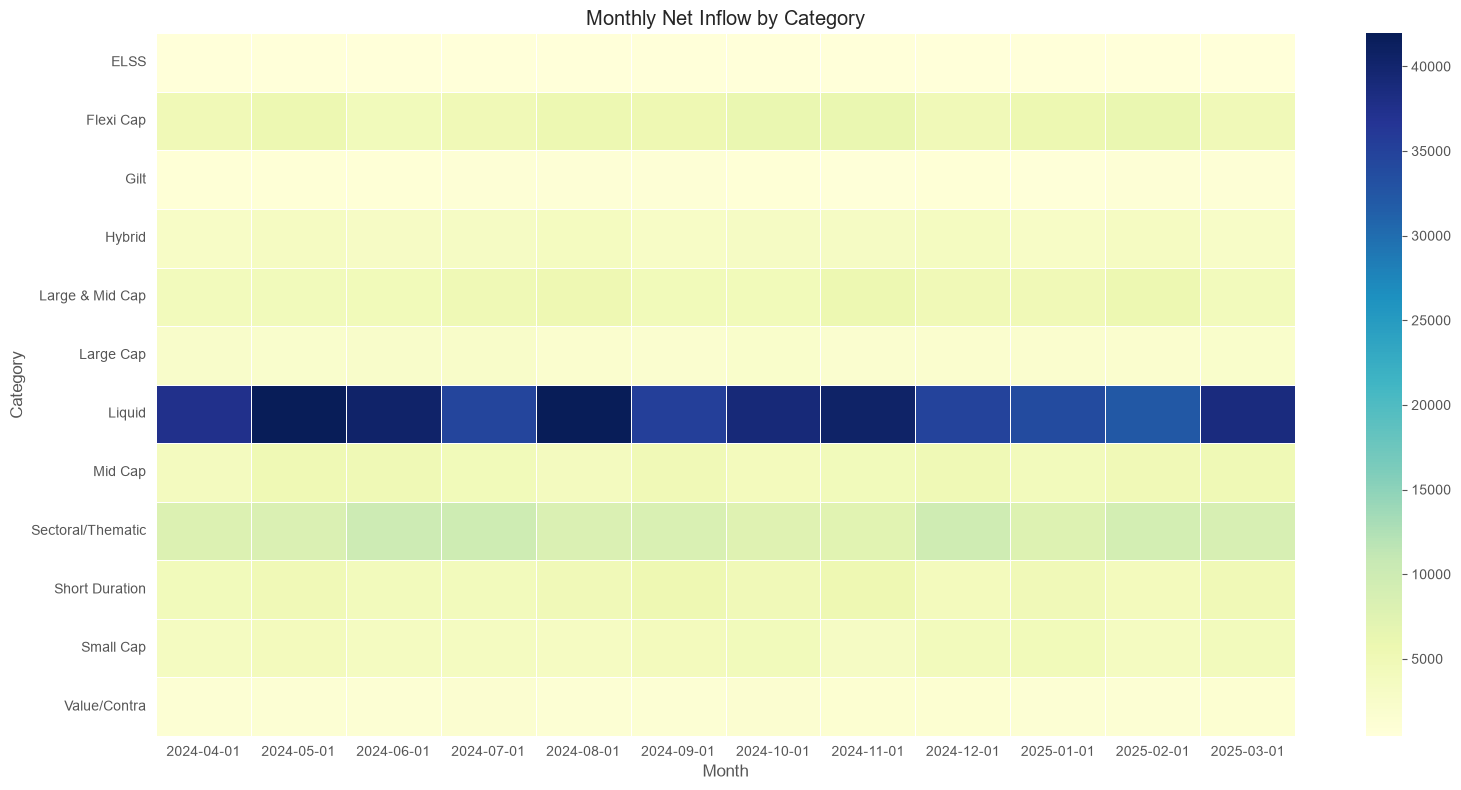

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Monthly Net Inflow by Category")

plt.xlabel("Month")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [48]:
monthly_top = (
    category.loc[
        category.groupby("month")["net_inflow_crore"].idxmax()
    ]
)

monthly_top

,month,category,net_inflow_crore,date
8,2024-04-01,Liquid,37537.0,2024-04-01
20,2024-05-01,Liquid,41872.0,2024-05-01
32,2024-06-01,Liquid,40486.0,2024-06-01
44,2024-07-01,Liquid,34643.0,2024-07-01
56,2024-08-01,Liquid,41952.0,2024-08-01
68,2024-09-01,Liquid,35308.0,2024-09-01
80,2024-10-01,Liquid,39091.0,2024-10-01
92,2024-11-01,Liquid,40506.0,2024-11-01
104,2024-12-01,Liquid,34933.0,2024-12-01
116,2025-01-01,Liquid,33892.0,2025-01-01


In [51]:
top5 = (
    category.groupby("category")["net_inflow_crore"]
    .sum()
    .nlargest(5)
    .index
)

top5

Index(['Liquid', 'Sectoral/Thematic', 'Flexi Cap', 'Large & Mid Cap', 'Short Duration'], dtype='str', name='category')

In [53]:
top5_data = category[
    category["category"].isin(top5)
].copy()

top5_data.head()

,month,category,net_inflow_crore,date
3,2024-04-01,Flexi Cap,4947.0,2024-04-01
4,2024-04-01,Large & Mid Cap,4214.0,2024-04-01
7,2024-04-01,Sectoral/Thematic,8052.0,2024-04-01
8,2024-04-01,Liquid,37537.0,2024-04-01
9,2024-04-01,Short Duration,4400.0,2024-04-01


In [54]:
fig = px.line(
    top5_data,
    x="date",
    y="net_inflow_crore",
    color="category",
    markers=True,
    title="Monthly Net Inflow of Top 5 Categories"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600
)

fig.show()

In [55]:
highest_category = category_total.idxmax()

highest_value = category_total.max()

print("Highest Inflow Category :", highest_category)

print("Total Inflow :", highest_value)

Highest Inflow Category : Liquid
Total Inflow : 451275.0


# Investor Demographics & Transaction Analysis

## Objective

Investor transaction data provides valuable insights into investment behavior, demographics, and participation patterns. This section analyzes investor characteristics such as gender, age group, transaction type, KYC status, and geographic distribution.

The objectives are:

- Study gender distribution of investors.
- Analyze age-group participation.
- Compare SIP investment amounts across age groups.
- Examine transaction type distribution.
- Analyze KYC compliance.
- Study state-wise investor participation.

In [56]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [57]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [58]:
transactions.describe(include="all")

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
count,32778,32778,32778.000000,32778,32778.000000,32778,32778,32778,32778,32778,32778.000000,32778,32778
unique,5000,516,NaN,3,NaN,12,24,2,5,2,NaN,4,2
top,INV001497,2025-04-28,NaN,SIP,NaN,Punjab,Kolkata,T30,26-35,Male,NaN,Net Banking,Verified
freq,12,88,NaN,19716,NaN,2965,2748,21719,13463,21809,NaN,8250,30146
mean,NaN,NaN,120264.617518,NaN,107437.318628,NaN,NaN,NaN,NaN,NaN,26.181219,NaN,NaN
std,NaN,NaN,14370.205345,NaN,150415.905084,NaN,NaN,NaN,NaN,NaN,20.805425,NaN,NaN
min,NaN,NaN,100016.000000,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
25%,NaN,NaN,118632.000000,NaN,3153.000000,NaN,NaN,NaN,NaN,NaN,10.600000,NaN,NaN
50%,NaN,NaN,119551.000000,NaN,17782.500000,NaN,NaN,NaN,NaN,NaN,19.700000,NaN,NaN
75%,NaN,NaN,120843.000000,NaN,189324.250000,NaN,NaN,NaN,NaN,NaN,37.400000,NaN,NaN


In [59]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [60]:
import plotly.express as px

gender = (
    transactions["gender"]
    .value_counts()
    .reset_index()
)

gender.columns = ["Gender","Count"]

fig = px.pie(
    gender,
    names="Gender",
    values="Count",
    title="Gender Distribution of Investors"
)

fig.show()

In [61]:
age = (
    transactions["age_group"]
    .value_counts()
    .sort_index()
)

age

age_group
18-25     4916
26-35    13463
36-45     8146
46-55     3779
56+       2474
Name: count, dtype: int64

In [62]:
fig = px.bar(
    age.reset_index(),
    x="age_group",
    y="count",
    title="Investor Age Group Distribution"
)

fig.show()

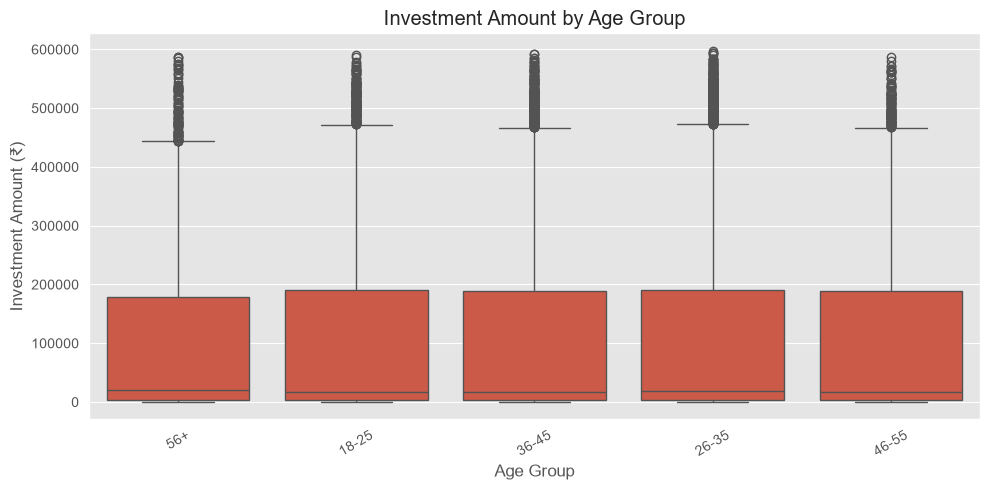

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [66]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [68]:
tx = (
    transactions["transaction_type"]
    .value_counts()
)

tx

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [69]:
fig = px.bar(
    tx.reset_index(),
    x="transaction_type",
    y="count",
    title="Transaction Type Distribution"
)

fig.show()

In [70]:
kyc = (
    transactions["kyc_status"]
    .value_counts()
)

kyc

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

In [71]:
fig = px.pie(
    kyc.reset_index(),
    names="kyc_status",
    values="count",
    title="KYC Status Distribution"
)

fig.show()

In [73]:
state = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

In [74]:
import plotly.express as px

fig = px.bar(
    state.reset_index(),
    x="amount_inr",
    y="state",
    orientation="h",
    title="Total Investment Amount by State",
    text="amount_inr"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=600,
    xaxis_title="Investment Amount (₹)",
    yaxis_title="State"
)

fig.show()

In [75]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

In [76]:
fig = px.pie(
    transactions,
    names="city_tier",
    title="T30 vs B30 Investors"
)

fig.show()

# Folio Growth Analysis

## Objective

A folio represents an investor account in a mutual fund. Tracking folio growth helps understand investor participation and the expansion of the mutual fund industry.

The objectives of this analysis are:

- Study the growth of total folios over time.
- Compare equity, debt, hybrid, and other folio categories.
- Calculate overall folio growth.
- Identify important milestones during the study period.

In [77]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [78]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [79]:
folio.describe()

,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,19.829524,13.880476,2.776190,1.190000,1.983333
std,4.583376,3.207799,0.640308,0.274864,0.459079
min,13.260000,9.280000,1.860000,0.800000,1.330000
25%,15.540000,10.880000,2.180000,0.930000,1.550000
50%,19.980000,13.990000,2.800000,1.200000,2.000000
75%,23.890000,16.720000,3.340000,1.430000,2.390000
max,26.120000,18.280000,3.660000,1.570000,2.610000


In [80]:
folio["date"] = pd.to_datetime(folio["month"])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore,date
0,2022-01-01,13.26,9.28,1.86,0.80,1.33,2022-01-01
1,2022-04-01,13.91,9.74,1.95,0.83,1.39,2022-04-01
2,2022-07-01,13.85,9.69,1.94,0.83,1.38,2022-07-01
3,2022-10-01,14.12,9.88,1.98,0.85,1.41,2022-10-01
4,2023-01-01,14.81,10.37,2.07,0.89,1.48,2023-01-01


In [81]:
import plotly.express as px

fig = px.line(
    folio,
    x="date",
    y="total_folios_crore",
    markers=True,
    title="Growth of Total Mutual Fund Folios (2022–2025)"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=550,
    xaxis_title="Year",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [83]:
start = folio.iloc[0]["total_folios_crore"]
end = folio.iloc[-1]["total_folios_crore"]

growth = ((end - start) / start) * 100

print("=" * 50)
print(f"Initial Folios : {start:.2f} Crore")
print(f"Final Folios   : {end:.2f} Crore")
print(f"Growth         : {growth:.2f}%")

Initial Folios : 13.26 Crore
Final Folios   : 26.12 Crore
Growth         : 96.98%


In [84]:
fig = px.line(
    folio,
    x="date",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    markers=True,
    title="Category-wise Folio Growth"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600,
    legend_title="Category"
)

fig.show()

In [85]:
fig = px.area(
    folio,
    x="date",
    y=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    title="Composition of Mutual Fund Folios"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=600
)

fig.show()

In [86]:
folio["year"] = folio["date"].dt.year

annual = (
    folio.groupby("year")["total_folios_crore"]
    .last()
    .reset_index()
)

annual

,year,total_folios_crore
0,2022,14.12
1,2023,16.72
2,2024,22.89
3,2025,26.12


In [87]:
fig = px.bar(
    annual,
    x="year",
    y="total_folios_crore",
    text="total_folios_crore",
    title="Year-wise Total Folios"
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=500
)

fig.show()

In [88]:
folio["year"] = folio["date"].dt.year

annual = (
    folio.groupby("year")["total_folios_crore"]
    .last()
    .reset_index()
)

annual

,year,total_folios_crore
0,2022,14.12
1,2023,16.72
2,2024,22.89
3,2025,26.12


In [89]:
fig = px.bar(
    annual,
    x="year",
    y="total_folios_crore",
    text="total_folios_crore",
    title="Year-wise Total Folios"
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=500
)

fig.show()

In [90]:
print("Starting Folios :", folio.iloc[0]["total_folios_crore"], "Crore")
print("Ending Folios   :", folio.iloc[-1]["total_folios_crore"], "Crore")

increase = (
    folio.iloc[-1]["total_folios_crore"]
    - folio.iloc[0]["total_folios_crore"]
)

print("Net Increase    :", round(increase, 2), "Crore")

Starting Folios : 13.26 Crore
Ending Folios   : 26.12 Crore
Net Increase    : 12.86 Crore


#  NAV Return Correlation Analysis

## Objective

Correlation analysis measures how similarly different mutual fund schemes move over time. By comparing daily NAV returns, we can identify highly correlated funds, diversification opportunities, and similarities in investment strategies.

Objectives:

- Compute daily percentage returns.
- Select representative schemes.
- Build a correlation matrix.
- Visualize correlations using a heatmap.
- Interpret diversification opportunities.

In [91]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [92]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [93]:
nav["date"] = pd.to_datetime(nav["date"])

In [94]:
nav2 = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

nav2.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [95]:
top10 = (
    nav2["scheme_name"]
    .dropna()
    .unique()[:10]
)

top10

<StringArray>
[         'HDFC Top 100 Fund - Regular Plan - Growth',       'HDFC Short Term Debt Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',      'ABSL Frontline Equity Fund - Regular - Growth',
             'ABSL Small Cap Fund - Regular - Growth',                'ABSL Liquid Fund - Regular - Growth',
         'UTI Nifty 50 Index Fund - Regular - Growth',                'UTI Mid Cap Fund - Regular - Growth',
              'UTI Flexi Cap Fund - Regular - Growth',     'Nippon India Large Cap Fund - Regular - Growth']
Length: 10, dtype: str

In [97]:
nav10 = nav2[
    nav2["scheme_name"].isin(top10)
].copy()

nav10.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [98]:
pivot = nav10.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

pivot.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,107.3758,26.3169,520.4608,42.8339,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,105.9447,26.2234,515.0971,42.8033,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,105.4800,26.2221,521.7239,43.0564,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,104.9350,26.1728,515.7880,43.2088,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,104.3318,26.2261,515.1639,42.9585,187.3124,124.1321,90.6762


In [99]:
returns = pivot.pct_change().dropna()

returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369
2022-01-10,0.011548,0.000690,0.001251,0.006277,0.006791,-0.008639,0.006360,-0.011593,-0.000722,-0.001202


In [100]:
corr = returns.corr()

corr

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038
HDFC Top 100 Fund - Regular Plan - Growth,0.027747,-0.033773,0.016053,-0.000006,0.045567,1.000000,-0.026781,-0.023316,-0.005867,-0.093533
Nippon India Large Cap Fund - Regular - Growth,-0.005432,0.003507,0.043384,-0.013318,-0.014166,-0.026781,1.000000,0.001248,-0.039886,-0.000285
UTI Flexi Cap Fund - Regular - Growth,-0.006490,0.036547,0.002304,-0.036647,-0.005648,-0.023316,0.001248,1.000000,-0.007865,-0.036704
UTI Mid Cap Fund - Regular - Growth,0.007229,0.014307,0.004860,-0.018166,0.013754,-0.005867,-0.039886,-0.007865,1.000000,0.020691


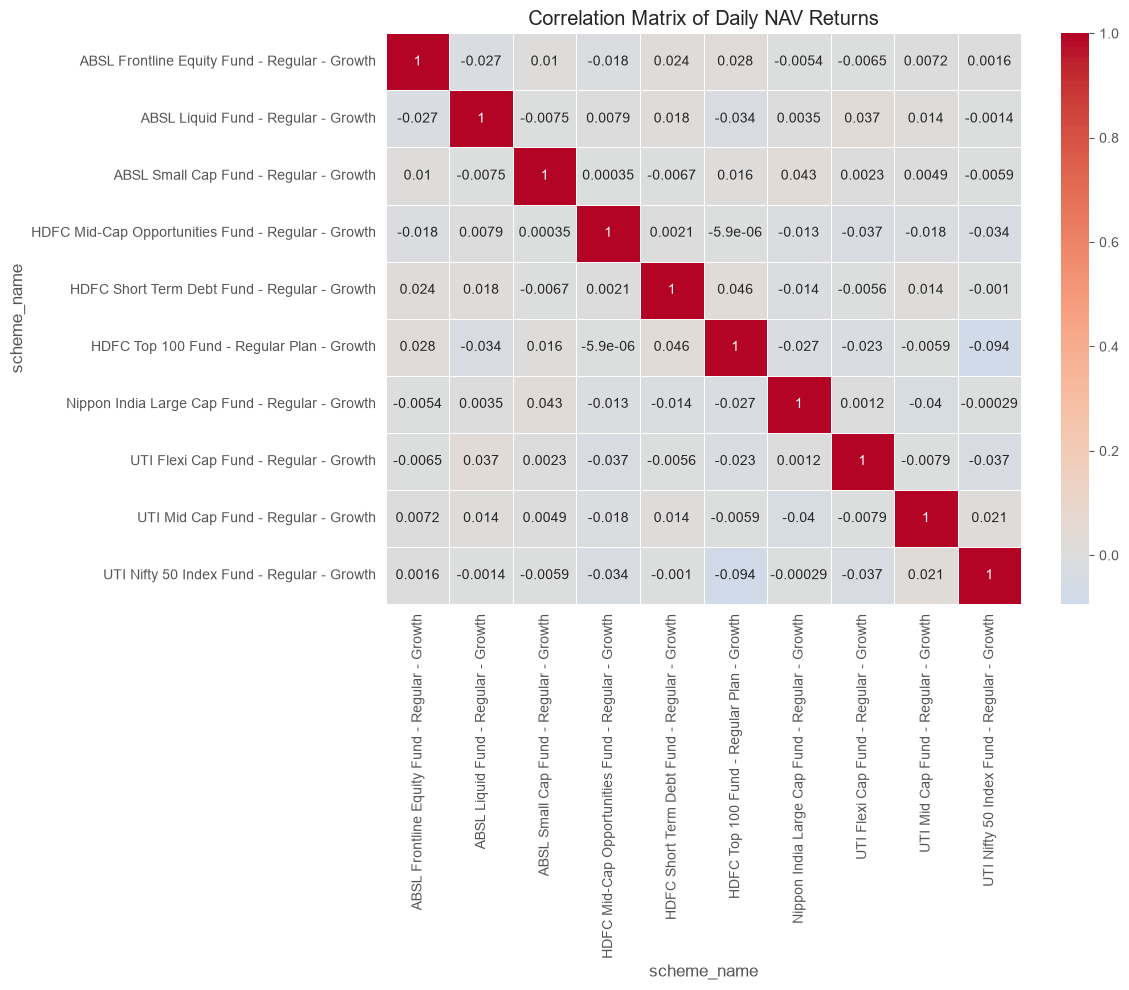

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.show()

In [102]:
corr_unstack = corr.unstack()

corr_unstack = corr_unstack[
    corr_unstack < 1
]

highest = corr_unstack.idxmax()

print("Highest Correlated Pair")
print(highest)

print("Correlation =", corr_unstack.max())

Highest Correlated Pair
('HDFC Short Term Debt Fund - Regular - Growth', 'HDFC Top 100 Fund - Regular Plan - Growth')
Correlation = 0.04556742536329194


In [103]:
nav.columns.tolist()

['amfi_code', 'date', 'nav']

# 12. Sector Allocation Analysis

## Objective

Portfolio holdings provide insight into where mutual funds allocate investor money. This analysis aggregates sector-wise allocations across all schemes to identify the dominant sectors in the portfolio.

Objectives:

- Analyze sector-wise allocation.
- Identify the largest sectors.
- Visualize allocation using a donut chart.
- Study diversification across industries.

In [104]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [105]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [106]:
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [107]:
holdings.describe(include="all")

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
count,322.000000,322,322,322,322.000000,322.000000,322.000000,322
unique,NaN,30,30,14,NaN,NaN,NaN,1
top,NaN,BHARTIARTL,Bharti Airtel Ltd,Banking,NaN,NaN,NaN,2025-12-31
freq,NaN,15,15,60,NaN,NaN,NaN,322
mean,121210.434783,NaN,NaN,NaN,10.558975,1008.846646,4080.870528,NaN
std,14669.377920,NaN,NaN,NaN,6.060137,543.827535,2265.186353,NaN
min,100016.000000,NaN,NaN,NaN,0.990000,55.740000,246.780000,NaN
25%,118633.000000,NaN,NaN,NaN,6.015000,513.702500,2081.985000,NaN
50%,119552.000000,NaN,NaN,NaN,9.395000,1045.670000,4138.995000,NaN
75%,120842.750000,NaN,NaN,NaN,13.917500,1477.502500,5914.307500,NaN


In [108]:
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [109]:
top10 = sector.head(10)

top10

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

In [110]:
import plotly.express as px

fig = px.pie(
    values=top10.values,
    names=top10.index,
    hole=0.55,
    title="Sector Allocation Across Mutual Funds"
)

fig.update_traces(textposition="inside")

fig.show()

In [111]:
fig = px.bar(
    x=top10.values,
    y=top10.index,
    orientation="h",
    title="Top 10 Portfolio Sectors"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Total Portfolio Weight (%)",
    yaxis_title="Sector"
)

fig.show()

In [112]:
largest_sector = sector.idxmax()

largest_weight = sector.max()

print("Largest Sector :", largest_sector)
print("Total Weight   :", round(largest_weight,2), "%")

Largest Sector : Banking
Total Weight   : 652.26 %


# 13. Key Findings

The exploratory data analysis revealed several important insights regarding the Indian mutual fund industry between 2022 and 2025.

---
### 1. Strong Growth in Mutual Fund Industry
Total Assets Under Management (AUM) increased consistently, reflecting strong investor confidence.

**Supporting Chart:** AUM Growth Analysis

---
### 2. Equity Funds Dominate Investments
Equity-oriented mutual funds attracted the largest proportion of investments compared with debt and hybrid funds.

**Supporting Chart:** Category-wise Inflow Analysis

---
### 3. SIP Investments Reached Record Highs
Monthly SIP inflows steadily increased throughout the study period, indicating increasing retail participation.

**Supporting Chart:** SIP Inflow Trend

---
### 4. Folio Count Nearly Doubled
Total folios increased from approximately 13.26 crore to more than 26 crore, demonstrating significant expansion in the investor base.

**Supporting Chart:** Folio Growth

---
### 5. SBI Mutual Fund Maintains Market Leadership
Among all fund houses, SBI Mutual Fund managed the highest Assets Under Management.

**Supporting Chart:** AUM by Fund House

---
### 6. Large Cap and Flexi Cap Schemes Attracted Significant Investments
Large Cap, Flexi Cap, and Sectoral funds received the highest net inflows during the analysis period.

**Supporting Chart:** Category Inflow Analysis

---
### 7. Digital Transactions Dominate
Most investors preferred digital payment methods for mutual fund investments.

**Supporting Chart:** Payment Mode Distribution

---
### 8. Investor Base Expanded Beyond Metropolitan Cities
B30 cities contributed a growing share of mutual fund investors, indicating deeper market penetration.

**Supporting Chart:** T30 vs B30 Distribution

---
### 9. Equity Funds Show High Correlation
Most equity mutual funds exhibited strong positive correlations due to similar market exposure.

**Supporting Chart:** NAV Correlation Matrix

---
### 10. Diversified Sector Allocation
Mutual fund portfolios maintained diversified exposure across Financials, IT, Healthcare, Manufacturing, and other sectors.

**Supporting Chart:** Sector Allocation Donut Chart